---
**Title:** 流水线并行 (Pipeline Parallelism, PP)

**Category:** pipeline-parallelism

**Difficulty:** 中级

**Estimated Time:** 45 分钟

---

## 概览

如果模型太大，一块 GPU 放不下怎么办？一个自然的想法：**把层分到多块 GPU 上**，每块 GPU 只放模型的一部分。

这就是**流水线并行**。本 notebook 会一步一步带你了解它 —— 从最简单的版本开始，逐步改进。

### 前置知识

- PyTorch 基础（`nn.Module`、`nn.Sequential`）
- 理解前向传播和反向传播
- 推荐先看：[00 — GPU 通信原语](00-gpu-communication.ipynb) 和 [01 — 数据并行](01-data-parallelism.ipynb)

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

# Our visualization helpers
from mp_tutorial.viz import draw_data_flow, draw_naive_vs_pipeline, draw_pipeline_timeline
from mp_tutorial.formatting import info_box, gpu_required_banner, comparison_table, code_reference
from mp_tutorial.distributed import check_gpu_env, simulate_pipeline_stages
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

check_gpu_env()

✗ No CUDA GPU detected on this machine.

To run GPU-required cells, use a machine with CUDA GPUs (4+ recommended).
See README.md for remote Jupyter setup instructions.


## 概念与原理

### 第一步：最简单的想法 —— 把层分开

假设有一个 8 层模型和 4 块 GPU，最自然的分法：

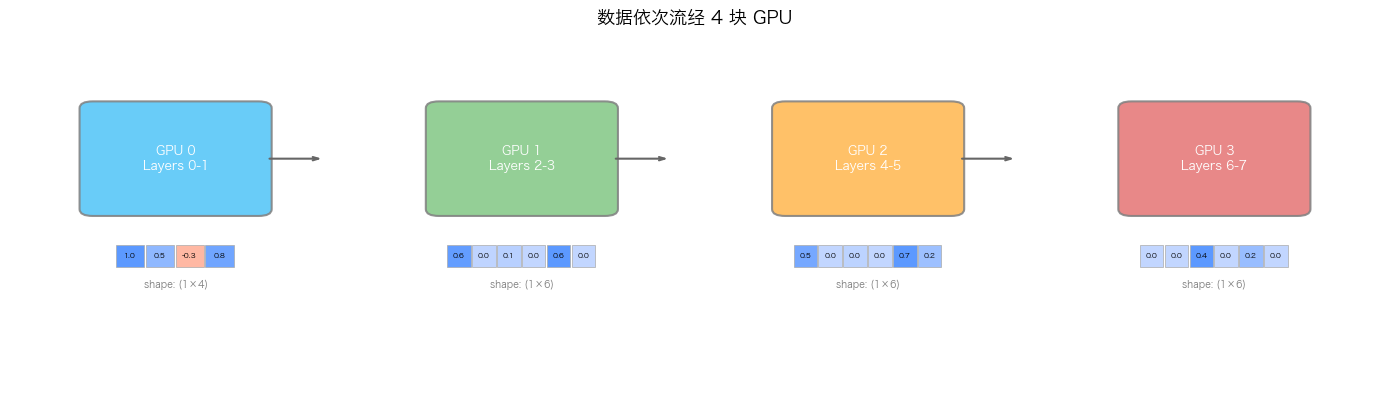

In [2]:
# Let's build a tiny model and watch data flow through it
torch.manual_seed(42)

# A simple 8-layer model (4 stages × 2 layers each)
model = nn.Sequential(
    nn.Linear(4, 6), nn.ReLU(),   # Stage 0 (GPU 0)
    nn.Linear(6, 6), nn.ReLU(),   # Stage 1 (GPU 1)
    nn.Linear(6, 6), nn.ReLU(),   # Stage 2 (GPU 2)
    nn.Linear(6, 3), nn.ReLU(),   # Stage 3 (GPU 3)
)

# One small input batch
x = torch.tensor([[1.0, 0.5, -0.3, 0.8]])

# Run through each stage and capture the intermediate tensors
stage_layers = [
    nn.Sequential(model[0], model[1]),  # GPU 0
    nn.Sequential(model[2], model[3]),  # GPU 1
    nn.Sequential(model[4], model[5]),  # GPU 2
    nn.Sequential(model[6], model[7]),  # GPU 3
]

snapshots = [x]
h = x
for stage in stage_layers:
    with torch.no_grad():
        h = stage(h)
    snapshots.append(h)

# Visualize: data flowing through each GPU
draw_data_flow(
    stage_labels=["GPU 0\nLayers 0-1", "GPU 1\nLayers 2-3",
                  "GPU 2\nLayers 4-5", "GPU 3\nLayers 6-7"],
    data_snapshots=snapshots,
    title="数据依次流经 4 块 GPU"
)
plt.show()

输入先到 GPU 0，GPU 0 的输出传给 GPU 1，以此类推。很简单！

但有一个**大问题**：当 GPU 1 在计算的时候，GPU 0、2、3 全都在**闲着**。让我们直观地看看：

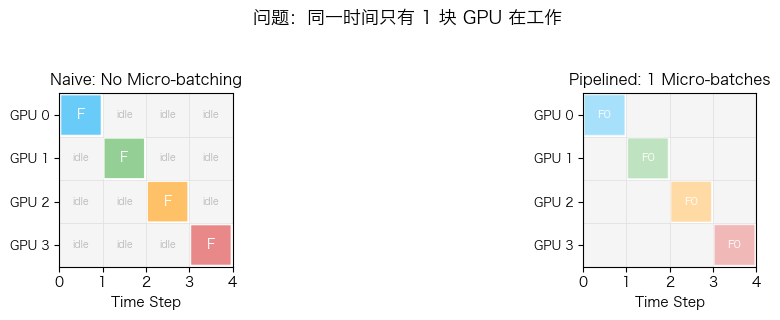

In [3]:
# Left: naive (1 batch, sequential)  vs  Right: with micro-batching
draw_naive_vs_pipeline(num_stages=4, num_microbatches=1, title="问题：同一时间只有 1 块 GPU 在工作")
plt.show()

4 块 GPU 只有 1 块在工作，浪费了 **75% 的算力**。我们需要更好的办法。

### 第二步：微批次（Micro-batching）—— 填满流水线

解决方法：不要把一整个 batch 一次性送进去，而是**拆成更小的块，叫做微批次**。

> **什么是微批次？** 正常训练时，你一次处理一"批"样本（比如 64 张图）。微批次就是把这批数据切成更小的块 —— 比如 8 个微批次，每个 8 张图。模型看到的数据是一样的，只是每次吃得少一点。

关键技巧：在微批次 #1 还没走完所有 GPU 之前，就把微批次 #2 **送进** GPU 0。这样多块 GPU 就能同时工作：

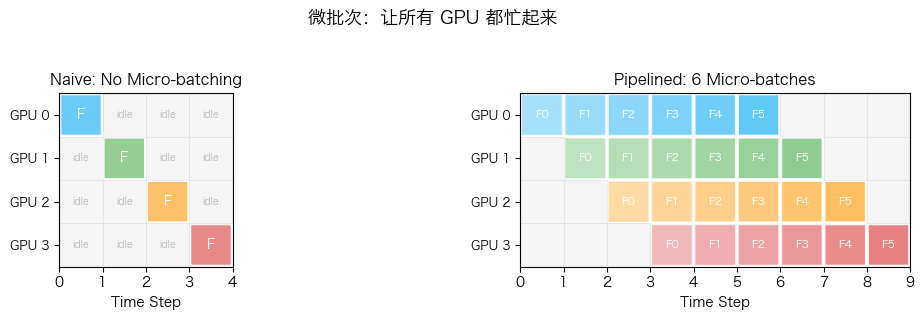

4 个阶段、6 个微批次：
  总时间步：9
  每个 GPU 的空闲步数：3
  气泡比例：3/9 = 33%

→ 微批次越多 = 浪费越少！


In [4]:
# Now with 6 micro-batches — see how the pipeline fills up!
draw_naive_vs_pipeline(num_stages=4, num_microbatches=6,
                       title="微批次：让所有 GPU 都忙起来")
plt.show()

# How much time is wasted?
p, m = 4, 6
total = m + p - 1
bubble = p - 1
print(f"{p} 个阶段、{m} 个微批次：")
print(f"  总时间步：{total}")
print(f"  每个 GPU 的空闲步数：{bubble}")
print(f"  气泡比例：{bubble}/{total} = {bubble/total:.0%}")
print(f"\n→ 微批次越多 = 浪费越少！")

灰色格子就是**流水线气泡（bubble）**—— GPU 闲着等数据到来或结果传递的时间。

> **为什么叫"气泡"？** 想象水管里的气泡 —— 那是没有水流过的空隙。在流水线里，气泡就是 GPU 无事可做的时间步。

气泡比例的公式是：

$$\text{气泡比例} = \frac{p - 1}{m + p - 1}$$

其中 $p$ = 阶段数（GPU 数），$m$ = 微批次数。微批次越多 → 气泡越小 → 效率越高。

### 第三步：动手试试 —— 在 CPU 上模拟流水线

让我们真正运行一个模型通过流水线阶段，看看数据怎么流动：

In [5]:
# Build a model and run it through simulated pipeline stages
torch.manual_seed(0)

model = nn.Sequential(
    nn.Linear(4, 8), nn.ReLU(),    # Stage 0
    nn.Linear(8, 8), nn.ReLU(),    # Stage 1
    nn.Linear(8, 8), nn.ReLU(),    # Stage 2
    nn.Linear(8, 3), nn.ReLU(),    # Stage 3
)

# Split a batch of 12 samples into 4 micro-batches of 3
batch = torch.randn(12, 4)
micro_batches = list(batch.chunk(4))

print(f"原始 batch: {batch.shape} → 拆分为 {len(micro_batches)} 个微批次，每个 {micro_batches[0].shape}\n")

outputs = simulate_pipeline_stages(model, num_stages=4, micro_batches=micro_batches)

原始 batch: torch.Size([12, 4]) → 拆分为 4 个微批次，每个 torch.Size([3, 4])

Pipeline: 8 layers split into 4 stages
  Stage 0: 2 layer(s)
  Stage 1: 2 layer(s)
  Stage 2: 2 layer(s)
  Stage 3: 2 layer(s)

=== Forward Pass ===
  [t= 0] Stage 0 processes micro-batch 0 → shape (3, 8)
  [t= 1] Stage 1 processes micro-batch 0 → shape (3, 8)
  [t= 2] Stage 2 processes micro-batch 0 → shape (3, 8)
  [t= 3] Stage 3 processes micro-batch 0 → shape (3, 3)
  [t= 1] Stage 0 processes micro-batch 1 → shape (3, 8)
  [t= 2] Stage 1 processes micro-batch 1 → shape (3, 8)
  [t= 3] Stage 2 processes micro-batch 1 → shape (3, 8)
  [t= 4] Stage 3 processes micro-batch 1 → shape (3, 3)
  [t= 2] Stage 0 processes micro-batch 2 → shape (3, 8)
  [t= 3] Stage 1 processes micro-batch 2 → shape (3, 8)
  [t= 4] Stage 2 processes micro-batch 2 → shape (3, 8)
  [t= 5] Stage 3 processes micro-batch 2 → shape (3, 3)
  [t= 3] Stage 0 processes micro-batch 3 → shape (3, 8)
  [t= 4] Stage 1 processes micro-batch 3 → shape (3, 8)
 

## 可视化

接下来看看不同的**调度策略**，它们是如何让流水线更高效的。

### GPipe 调度

最简单的方式：先跑完**所有前向传播**，再跑**所有反向传播**。

看下面的调度网格 —— 每个彩色方块是一个正在处理的微批次。灰色 = 气泡（空闲）。

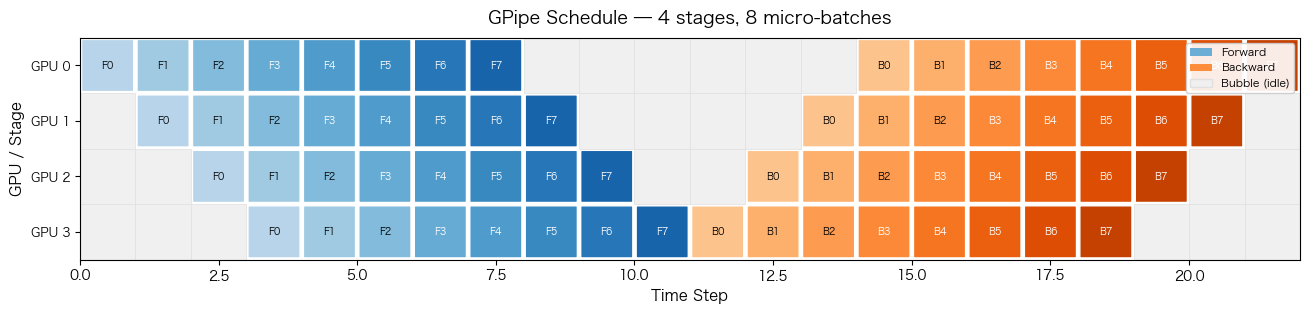

In [6]:
# GPipe：先跑完所有前向，再跑所有反向
fig, ax = draw_pipeline_timeline(num_stages=4, num_microbatches=8, schedule="gpipe")
plt.show()

info_box(
    "GPipe 简单但内存开销大：它必须同时保存所有 8 个微批次的<b>激活值</b>"
    "（反向传播需要用到）。"
    "<br><br>"
    "<b>什么是激活值？</b>前向传播时，每一层都会产生中间输出（激活值）。"
    "这些必须留在内存里，因为反向传播计算梯度时需要用到它们。"
    "同时处理的微批次越多 = 存的激活值越多 = 占用的 GPU 内存越大。"
    "<br><br>"
    "内存开销：O(m)，m = 微批次数。",
    title="GPipe 内存"
)

### 1F1B 调度（一前一后）

更聪明的做法：GPU 做完一个前向传播后，立刻开始**反向传播**，而不是傻等着。这样**交替进行**前向和反向：

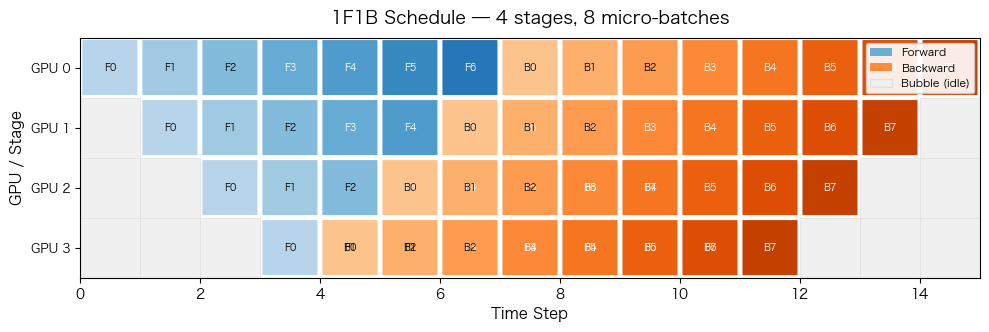

In [7]:
# 1F1B: interleave forward and backward passes
fig, ax = draw_pipeline_timeline(num_stages=4, num_microbatches=8, schedule="1f1b")
plt.show()

info_box(
    "1F1B 的气泡比例和 GPipe 一样，但内存少得多！"
    "每块 GPU 只需要保存 O(p) 个微批次的激活值"
    "（正在处理中的），而不是全部 m 个。"
    "p=4 时：内存从 O(8) 降到 O(4)。",
    title="1F1B 的优势"
)

### 对比各种调度策略

把关键区别放在一起看：

In [8]:
p, m = 4, 8
comparison_table(
    headers=["调度策略", "气泡比例", "峰值内存", "复杂度"],
    rows=[
        ["朴素（无微批次）", f"{(p-1)/p:.0%}", "O(1)", "极简"],
        ["GPipe", f"{(p-1)/(m+p-1):.0%}", "O(m) = O(8)", "简单"],
        ["1F1B", f"{(p-1)/(m+p-1):.0%}", "O(p) = O(4)", "中等"],
        ["交错 (v=2)", f"{(p-1)/(2*m+p-1):.0%}", "O(p) = O(4)", "复杂"],
    ],
    title=f"流水线调度对比（p={p} 阶段，m={m} 微批次）"
)

调度策略,气泡比例,峰值内存,复杂度
朴素（无微批次）,75%,O(1),极简
GPipe,27%,O(m) = O(8),简单
1F1B,27%,O(p) = O(4),中等
交错 (v=2),16%,O(p) = O(4),复杂


### 交错虚拟阶段（进阶）

Megatron-LM 的技巧：给每块 GPU 分配**多组不连续的层**（虚拟阶段），进一步减少气泡。

例如 4 块 GPU、每块 2 个虚拟阶段：
- GPU 0：第 0–1 层 **和** 第 8–9 层
- GPU 1：第 2–3 层 **和** 第 10–11 层
- ...

气泡比例降低为：$\frac{p-1}{v \cdot m + p-1}$（$v$ = 每块 GPU 的虚拟阶段数）。代价是更多通信 —— 数据要经过每块 GPU $v$ 次。

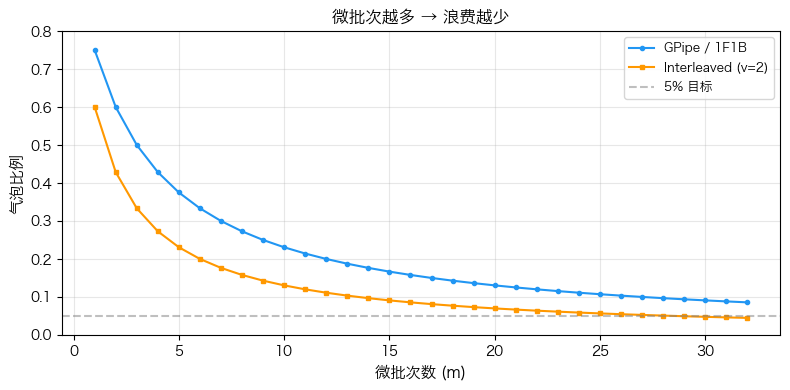

In [9]:
# How bubble fraction changes with more micro-batches
stages = 4
ms = range(1, 33)
bubble_gpipe = [(stages - 1) / (m + stages - 1) for m in ms]
bubble_interleaved = [(stages - 1) / (2 * m + stages - 1) for m in ms]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(ms), bubble_gpipe, 'o-', color="#2196F3", label="GPipe / 1F1B", markersize=3)
ax.plot(list(ms), bubble_interleaved, 's-', color="#FF9800", label="Interleaved (v=2)", markersize=3)
ax.axhline(y=0.05, color='gray', linestyle='--', alpha=0.5, label="5% 目标")
ax.set_xlabel("微批次数 (m)", fontsize=11)
ax.set_ylabel("气泡比例", fontsize=11)
ax.set_title("微批次越多 → 浪费越少", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 0.8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 在大语言模型中的应用

流水线并行在所有最大的语言模型训练中都有使用：

- **GPT-3 (175B)**：8 路 PP × 8 路 TP，共 64 块 GPU。PP 负责节点间通信（成本低：只需相邻阶段点对点传输）
- **Megatron-Turing NLG (530B)**：8 PP × 8 TP × 35 DP = 2240 块 GPU，使用交错调度
- **通用法则**：TP 在节点内（高速 NVLink），PP 在节点间（只需点对点），DP 跨副本

> **术语说明：**
> - *节点* = 一台物理服务器，通常有 8 块 GPU，通过高速 **NVLink** 连接（600+ GB/s）
> - *跨节点* = 服务器之间的通信，走较慢的网络（InfiniBand，~400 GB/s）
> - *AllReduce* = 每块 GPU 都要和所有其他 GPU 通信（开销大）。*点对点* = 只和邻居通信（开销小）
> - 这就是为什么 PP 适合跨节点 —— 它只需要和上一个/下一个阶段通信！

In [10]:
# Why PP is preferred for inter-node communication
comparison_table(
    headers=["并行方式", "通信模式", "最适合"],
    rows=[
        ["数据并行 (DP)", "AllReduce（所有 GPU 互相通信）", "多副本，相同模型"],
        ["张量并行 (TP)", "每层内 AllReduce", "节点内（高速 NVLink）"],
        ["流水线并行 (PP)", "点对点（仅相邻阶段）", "跨节点（较慢网络）"],
    ],
    title="为什么 PP 是跨节点并行的首选"
)

并行方式,通信模式,最适合
数据并行 (DP),AllReduce（所有 GPU 互相通信）,多副本，相同模型
张量并行 (TP),每层内 AllReduce,节点内（高速 NVLink）
流水线并行 (PP),点对点（仅相邻阶段）,跨节点（较慢网络）


## 动手代码

### 需要 GPU：使用 PyTorch Pipe 进行真正的流水线训练

In [11]:
gpu_required_banner()

In [ ]:
# [GPU-REQUIRED]
# Save as pp_train.py and run: torchrun --nproc_per_node=4 pp_train.py

"""
import torch
import torch.nn as nn
from torch.distributed.pipeline.sync import Pipe

# Place layers on different GPUs
model = nn.Sequential(
    nn.Linear(256, 512).cuda(0), nn.ReLU().cuda(0),
    nn.Linear(512, 512).cuda(1), nn.ReLU().cuda(1),
    nn.Linear(512, 256).cuda(2), nn.ReLU().cuda(2),
    nn.Linear(256, 10).cuda(3),
)

# Pipe handles micro-batch splitting automatically
pipe_model = Pipe(model, chunks=8)

optimizer = torch.optim.Adam(pipe_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for step in range(10):
    x = torch.randn(32, 256).cuda(0)
    target = torch.randint(10, (32,)).cuda(3)

    out = pipe_model(x)
    loss = loss_fn(out.local_value(), target)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"Step {step}: loss={loss.item():.4f}")
"""
print("参见上方代码 —— 运行方式：torchrun --nproc_per_node=4 pp_train.py")

## Megatron 参考

Megatron-LM 的流水线调度实现在 `megatron/core/pipeline_parallel/schedules.py`，以下是两个关键函数：

In [12]:
code_reference(
    code="""def forward_backward_pipelining_without_interleaving(...):
    # 1F1B Schedule
    # Phase 1: Warmup — fill pipeline with forward passes
    for i in range(num_warmup_microbatches):
        output = forward_step(...)
        send_forward(output)

    # Phase 2: Steady state — alternate 1 forward, 1 backward
    for i in range(num_microbatches_remaining):
        output = forward_step(...)
        send_forward(output)
        grad = backward_step(...)
        send_backward(grad)

    # Phase 3: Cooldown — drain remaining backward passes
    for i in range(num_warmup_microbatches):
        grad = backward_step(...)
        send_backward(grad)""",
    source="Megatron-LM",
    filepath="megatron/core/pipeline_parallel/schedules.py"
)

## 总结与延伸阅读

### 要点回顾

1. **流水线并行**把模型的层分到多块 GPU 上 —— 每块 GPU 负责一个"阶段"
2. 没有微批次的话，同一时间只有 1 块 GPU 在工作 —— 利用率极低
3. **微批次**填满流水线：把 batch 拆成 $m$ 份，让计算重叠
4. **气泡比例** $= \frac{p-1}{m+p-1}$ —— 用 $m \gg p$ 来减少浪费
5. **GPipe**：简单（先全部前向再全部反向），但内存高（$O(m)$）
6. **1F1B**：相同气泡，但通过交替前向/反向将内存降至 $O(p)$
7. **交错阶段**：气泡再降 $v$ 倍，代价是更多通信

### 延伸阅读

- [GPipe (Huang et al., 2019)](https://arxiv.org/abs/1811.06965) — 微批次流水线并行
- [PipeDream (Narayanan et al., 2019)](https://arxiv.org/abs/1806.03377) — 1F1B 调度
- [高效大规模训练 (Narayanan et al., 2021)](https://arxiv.org/abs/2104.04473) — Megatron-LM 交错调度
- [PyTorch 流水线并行文档](https://pytorch.org/docs/stable/pipeline.html)
- [Megatron-LM](https://github.com/NVIDIA/Megatron-LM) — `megatron/core/pipeline_parallel/`